In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
    --------------------------------------- 1.0/69.5 MB 9.3 MB/s eta 0:00:08
   - -------------------------------------- 3.4/69.5 MB 11.1 MB/s eta 0:00:06
   --- ------------------------------------ 5.8/69.5 MB 11.4 MB/s eta 0:00:06
   ---- ----------------------------------- 8.4/69.5 MB 11.5 MB/s eta 0:00:06
   ------ --------------------------------- 11.0/69.5 MB 11.6 MB/s eta 0:00:06
   ------- -------------------------------- 13.6/69.5 MB 11.6 MB/s eta 0:00:05
   --------- ------------------------------ 16.0/69.5 MB 11.7 MB/s eta 0:00:05
   ---------- ----------------------------- 18.6/69.5 MB 11.7 MB/s eta 0:00:05
   ------------ --------------------------- 21.2/69.5 MB 11.7 MB/s eta 0:00:05
   ------------- -------------------------- 23.6/69.5 MB 11.7 MB/s eta 0:00:04
   --------------- ------------------------ 26.2/69.5 MB 11.7 MB/s eta 0:00:04
   ---------------- ----------------------- 28.6/69.5 MB 11.7 MB/s

In [2]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [3]:
# LOAD DATASET

df = pd.read_csv("../data/Retail_Transaction_Dataset.csv")
print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
0,109318,C,7,80.079844,12/26/2023 12:32,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,8/5/2023 0:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,3/11/2024 18:51,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,10/27/2023 22:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,12/22/2023 11:38,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484


In [4]:
# DATASET INFORMATION

print("Shape of Dataset:", df.shape)
print("\n")
df.info()

Shape of Dataset: (100000, 10)


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CustomerID          100000 non-null  int64  
 1   ProductID           100000 non-null  str    
 2   Quantity            100000 non-null  int64  
 3   Price               100000 non-null  float64
 4   TransactionDate     100000 non-null  str    
 5   PaymentMethod       100000 non-null  str    
 6   StoreLocation       100000 non-null  str    
 7   ProductCategory     100000 non-null  str    
 8   DiscountApplied(%)  100000 non-null  float64
 9   TotalAmount         100000 non-null  float64
dtypes: float64(3), int64(2), str(5)
memory usage: 7.6 MB


In [5]:
# MISSING VALUES

df.isnull().sum()

CustomerID            0
ProductID             0
Quantity              0
Price                 0
TransactionDate       0
PaymentMethod         0
StoreLocation         0
ProductCategory       0
DiscountApplied(%)    0
TotalAmount           0
dtype: int64

In [6]:
# DUPLICATE RECORDS

print("Duplicate Rows =", df.duplicated().sum())

Duplicate Rows = 0


In [7]:
# STATISTICAL SUMMARY

df.describe(include='all')

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
count,100000.00000,100000,100000.00000,100000.000000,100000,100000,100000,100000,100000.000000,100000.000000
unique,NaN,4,NaN,NaN,91025,4,100000,4,NaN,NaN
top,NaN,C,NaN,NaN,4/3/2024 23:55,PayPal,"176 Andrew Cliffs\nBaileyfort, HI 93354",Clothing,NaN,NaN
freq,NaN,25209,NaN,NaN,5,25067,1,25056,NaN,NaN
mean,500463.98218,NaN,5.00929,55.067344,NaN,NaN,NaN,NaN,10.020155,248.334955
...,...,...,...,...,...,...,...,...,...,...
min,14.00000,NaN,1.00000,10.000430,NaN,NaN,NaN,NaN,0.000046,8.274825
25%,250693.75000,NaN,3.00000,32.549474,NaN,NaN,NaN,NaN,5.001013,95.163418
50%,499679.00000,NaN,5.00000,55.116789,NaN,NaN,NaN,NaN,10.030353,200.368393
75%,751104.75000,NaN,7.00000,77.456763,NaN,NaN,NaN,NaN,15.018367,362.009980


In [8]:
# DATA TYPES

df.dtypes

CustomerID              int64
ProductID                 str
Quantity                int64
Price                 float64
TransactionDate           str
PaymentMethod             str
StoreLocation             str
ProductCategory           str
DiscountApplied(%)    float64
TotalAmount           float64
dtype: object

In [9]:
# UNIQUE VALUES

for col in df.columns:
    print(col, ":", df[col].nunique())

CustomerID : 95215
ProductID : 4
Quantity : 9
Price : 100000
TransactionDate : 91025
PaymentMethod : 4
StoreLocation : 100000
ProductCategory : 4
DiscountApplied(%) : 100000
TotalAmount : 99998


In [10]:
# CONVERT TRANSACTION DATE

df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
print(df["TransactionDate"].dtype)

datetime64[us]


In [11]:
# DATE RANGE

print("Start Date :", df["TransactionDate"].min())
print("End Date   :", df["TransactionDate"].max())

Start Date : 2023-04-29 22:27:00
End Date   : 2024-04-28 22:22:00


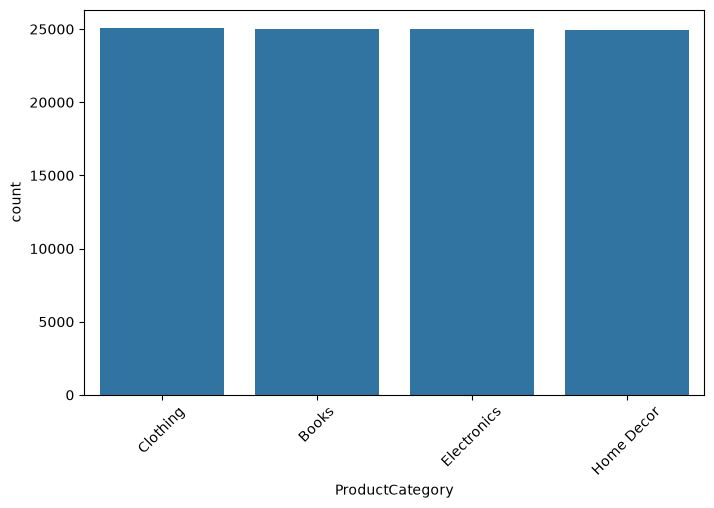

In [12]:
# SALES BY PRODUCT CATEGORY

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="ProductCategory", order=df["ProductCategory"].value_counts().index)
plt.xticks(rotation=45)
plt.show()

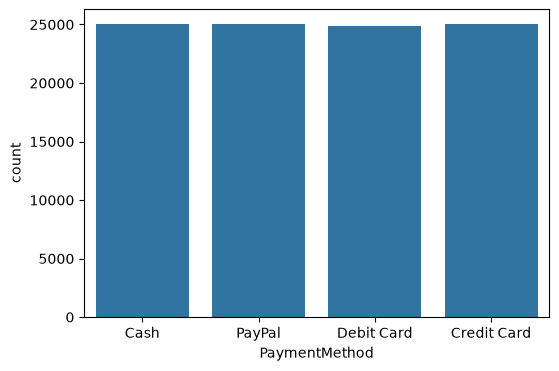

In [13]:
# PAYMENT METHOD DISTRIBUTION

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="PaymentMethod")
plt.show()

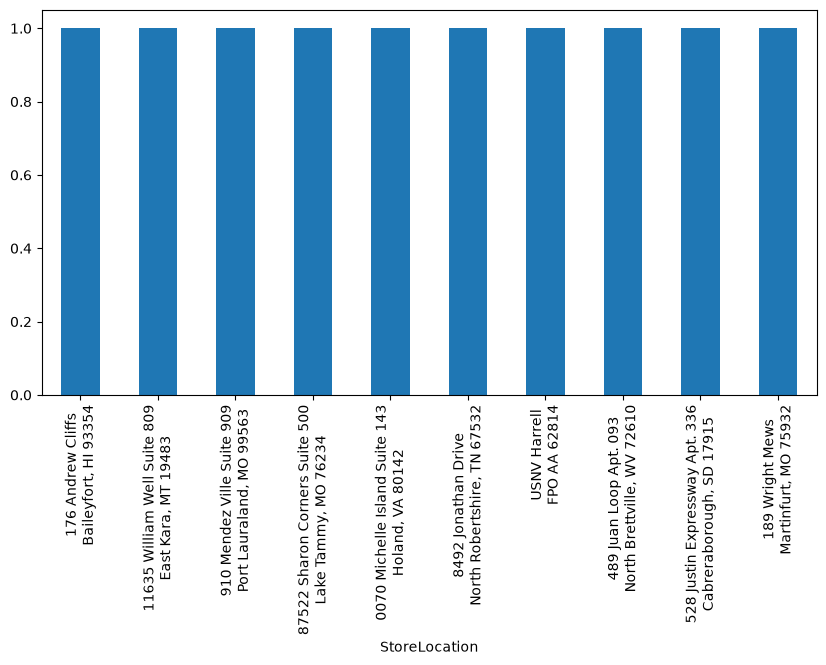

In [14]:
# TOP STORE LOCATIONS

plt.figure(figsize=(10,5))
df["StoreLocation"].value_counts().head(10).plot(kind="bar")
plt.show()

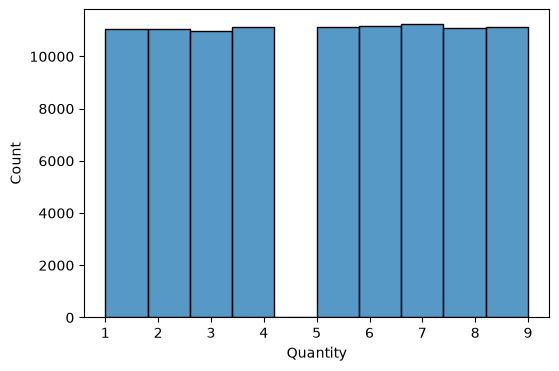

In [15]:
# QUANTITY DISTRIBUTION

plt.figure(figsize=(6,4))
sns.histplot(df["Quantity"], bins=10)
plt.show()

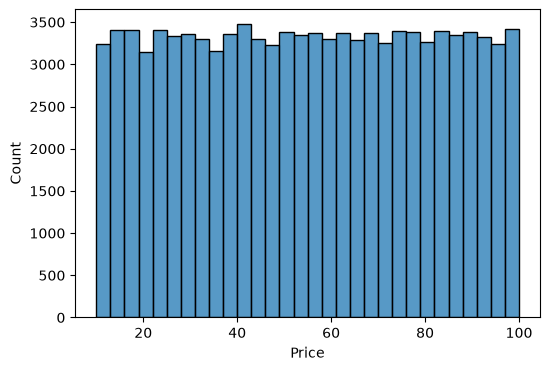

In [16]:
# PRICE DISTRIBUTION

plt.figure(figsize=(6,4))
sns.histplot(df["Price"], bins=30)
plt.show()

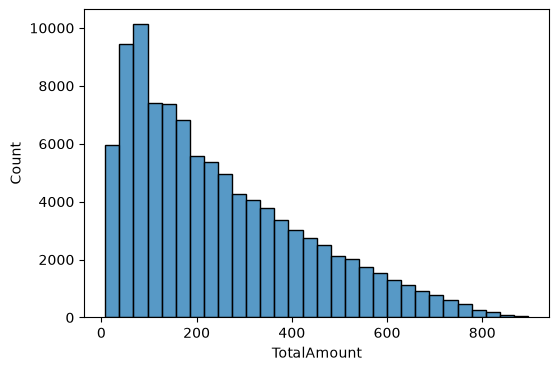

In [17]:
# TOTAL AMOUNT DISTRIBUTION

plt.figure(figsize=(6,4))
sns.histplot(df["TotalAmount"], bins=30)
plt.show()

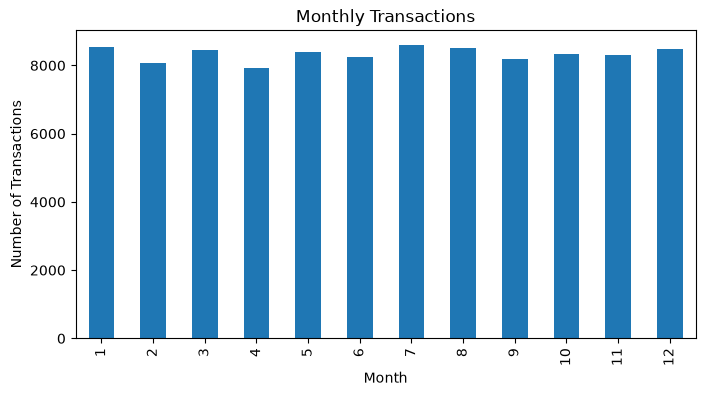

In [18]:
# MONTHLY TRANSACTIONS

monthly_transactions = df.groupby(df["TransactionDate"].dt.month).size()

monthly_transactions.plot(kind="bar", figsize=(8,4))

plt.title("Monthly Transactions")

plt.xlabel("Month")

plt.ylabel("Number of Transactions")

plt.show()

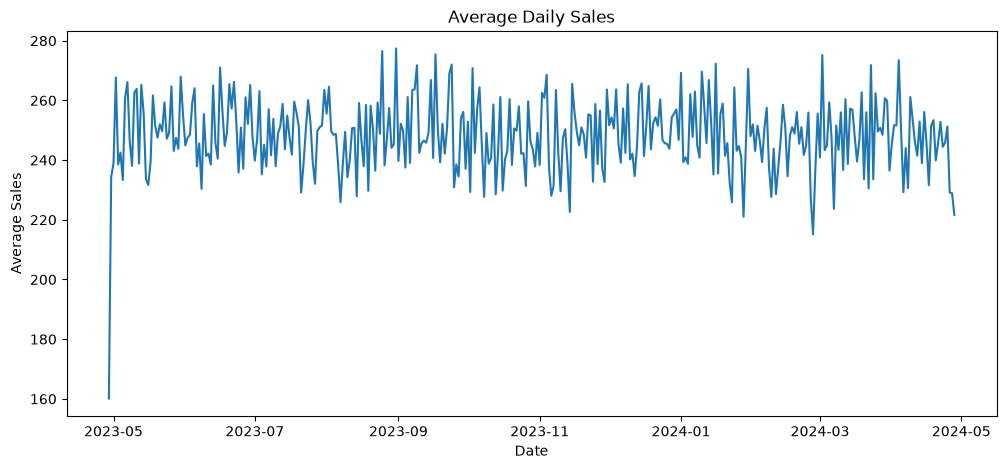

In [19]:
# AVERAGE DAILY SALES

daily_avg = df.groupby(df["TransactionDate"].dt.date)["TotalAmount"].mean()

daily_avg.plot(figsize=(12,5))

plt.title("Average Daily Sales")

plt.xlabel("Date")

plt.ylabel("Average Sales")

plt.show()

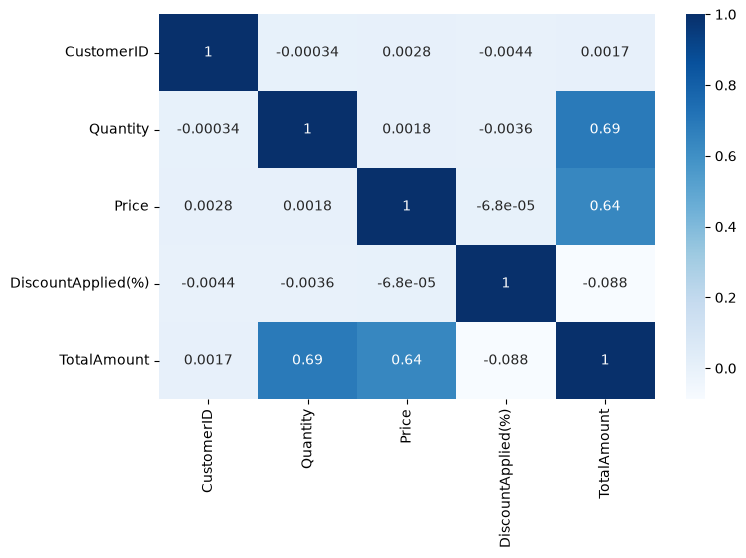

In [20]:
# CORRELATION MATRIX

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.show()